# NB-04: Evaluation

**Purpose:** Evaluate the trained model on the test set.

**Metrics:**
- Per-class precision, recall, F1-score
- 6×6 confusion matrix
- Binary anomaly detection (Normal vs Crime): precision, recall, F1, AUC-ROC
- Per-class ROC curves

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support,
)
from tqdm import tqdm

from src.model import AnomalyMobileMamba, CLASS_NAMES, NUM_CLASSES
from src.dataset import CrimeFrameDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Can not import selective_scan_cuda_oflex. This affects speed.


c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\model\lib_mamba\csm_triton.py:11: UserWarning: Triton not installed, fall back to pytorch implements. (Error: No module named 'triton')
  warnings.warn(f"Triton not installed, fall back to pytorch implements. (Error: {e})")
c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\model\lib_mamba\csms6s.py:13: UserWarning: Can not import selective_scan_cuda_oflex. This affects speed.
  warnings.warn("Can not import selective_scan_cuda_oflex. This affects speed.")
c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\model\lib_mamba\csms6s.py:73: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_ty

Device: cuda


In [2]:
# ─── Load Model ───────────────────────────────────────
model = AnomalyMobileMamba(num_classes=NUM_CLASSES)
ckpt = torch.load('../checkpoints/best_model.pth', map_location='cpu')
model.load_state_dict(ckpt['model'])
model = model.to(DEVICE)
model.eval()

print(f'Best model loaded (val_acc={ckpt.get("val_acc", "N/A")})')

# ─── Load Test Data ───────────────────────────────────
test_ds = CrimeFrameDataset('../data/frames', split='test', img_size=256)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4)

Best model loaded (val_acc=0.3815789473684211)
[TEST] Loaded 2016 frames  |  Distribution: {'Normal': 256, 'Assault': 256, 'Robbery': 736, 'Shooting': 256, 'Fighting': 256, 'Abuse': 256}


In [3]:
# ─── Run Inference on Test Set ─────────────────────────
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

overall_acc = (all_preds == all_labels).mean()
print(f'\nOverall Test Accuracy: {overall_acc * 100:.2f}%')

Evaluating: 100%|██████████| 32/32 [00:50<00:00,  1.59s/it]


Overall Test Accuracy: 37.05%


In [4]:
# ─── Classification Report ────────────────────────────
print('\n' + '=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(all_labels, all_preds,
                            target_names=CLASS_NAMES, digits=3))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal      0.455     0.668     0.541       256
     Assault      0.154     0.008     0.015       256
     Robbery      0.693     0.429     0.530       736
    Shooting      0.126     0.070     0.090       256
    Fighting      0.209     0.293     0.244       256
       Abuse      0.246     0.645     0.356       256

    accuracy                          0.371      2016
   macro avg      0.314     0.352     0.296      2016
weighted avg      0.404     0.371     0.352      2016



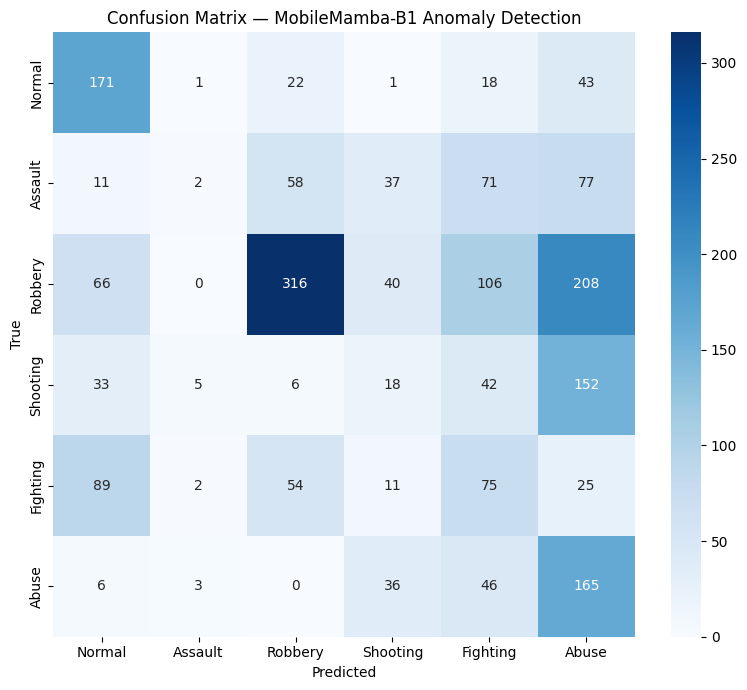

In [5]:
# ─── Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — MobileMamba-B1 Anomaly Detection')
plt.tight_layout()
plt.savefig('../outputs/logs/confusion_matrix.png', dpi=150)
plt.show()


BINARY ANOMALY DETECTION
Precision: 0.9482
Recall:    0.8835
F1-Score:  0.9147
AUC-ROC:   0.8643


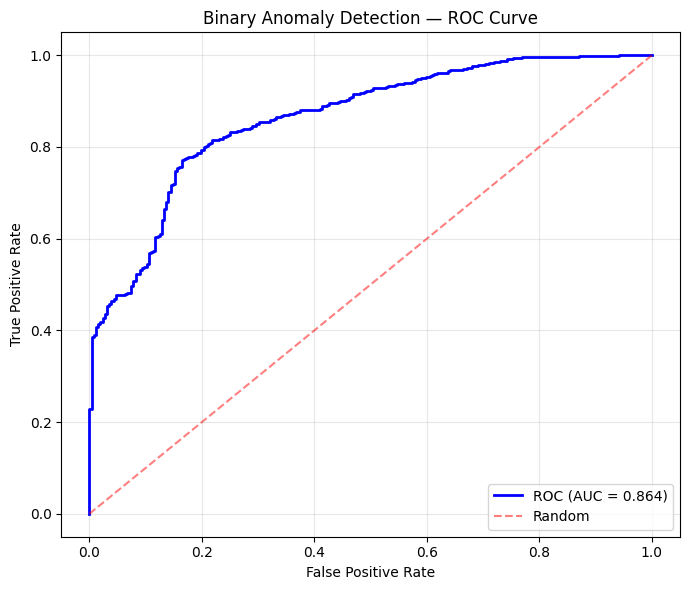

In [6]:
# ─── Binary Anomaly Detection ─────────────────────────
# Normal = 0 (negative), all crime classes = 1 (positive)
binary_labels = (all_labels > 0).astype(int)
binary_preds = (all_preds > 0).astype(int)
anomaly_scores = 1 - all_probs[:, 0]  # P(anomaly) = 1 - P(Normal)

precision, recall, f1, _ = precision_recall_fscore_support(
    binary_labels, binary_preds, average='binary'
)

fpr, tpr, _ = roc_curve(binary_labels, anomaly_scores)
roc_auc = auc(fpr, tpr)

print('\n' + '=' * 60)
print('BINARY ANOMALY DETECTION')
print('=' * 60)
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'AUC-ROC:   {roc_auc:.4f}')

# ROC curve
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Binary Anomaly Detection — ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/logs/binary_roc_curve.png', dpi=150)
plt.show()

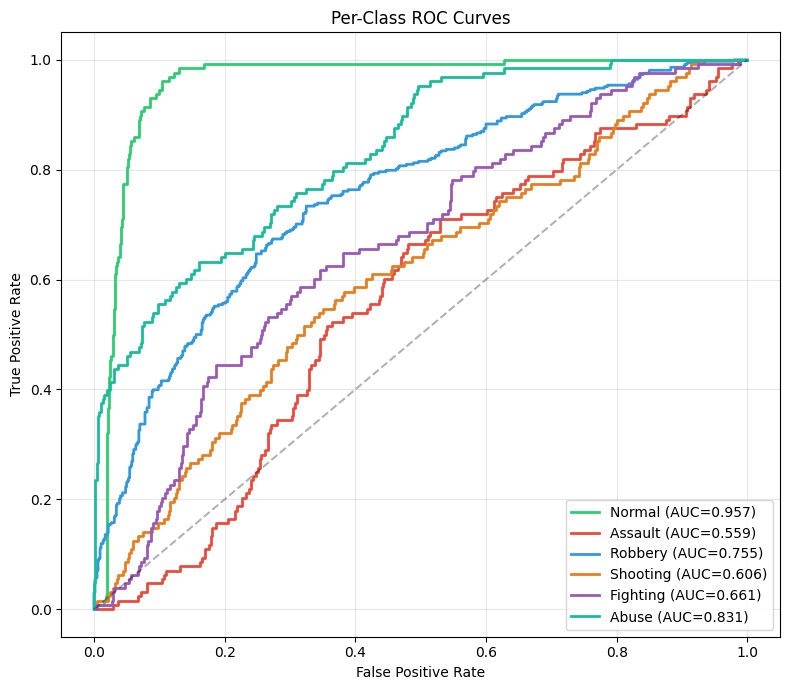

In [9]:
# ─── Per-Class ROC Curves ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22', '#9b59b6', '#1abc9c']

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    binary_true = (all_labels == i).astype(int)
    class_scores = all_probs[:, i]
    fpr_c, tpr_c, _ = roc_curve(binary_true, class_scores)
    auc_c = auc(fpr_c, tpr_c)
    ax.plot(fpr_c, tpr_c, color=color, linewidth=2,
            label=f'{name} (AUC={auc_c:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Per-Class ROC Curves')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/logs/per_class_roc_curves.png', dpi=150)
plt.show()